# M5 — Calls and puts: price protection with a premium

Options can protect against an unfavorable price move while allowing the holder to benefit from a favorable one. That flexibility has a cost: the premium paid for the option. This lesson calculates both the option payment and the business result after including that premium.

Read [M4](M4_price_quantity_scenarios.ipynb) first. A **call option** can protect a buyer against a rising price. A **put option** can protect a seller against a falling price. We examine the buyer and supplier as separate businesses, each purchasing its own protection.

All terms are **hypothetical**. Each needs protection for 7,200 GPU-hours in month 12, with a USD 5 agreed price, or **strike**. The call costs USD 0.40 per covered hour today; the put costs USD 0.30. That upfront price is the **premium**.

Our options pay cash only at the end of month 12. This end-date-only rule is called **European**. No early exercise or collateral is required here. Actual compute price initially matches the option's benchmark.

The options supply money, not computers. [OIC's call](https://www.optionseducation.org/strategies/all-strategies/long-call) and [put explanations](https://www.optionseducation.org/strategies/all-strategies/long-put) explain the terms; they do not show that these compute products are available.

In [1]:
# Install the teaching package from GitHub when running in Google Colab.
# Local Jupyter uses the repository's existing environment.
import subprocess
import sys

if "google.colab" in sys.modules:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "liquid-compute[colab] @ git+https://github.com/zach189/education.git@main",
        ]
    )
    from google.colab import output

    output.enable_custom_widget_manager()

In [2]:
from IPython.display import display

from liquid_compute.education import (
    explore_finance_series,
    plot_finance_series,
    show_finance_table,
)
from liquid_compute.hedging import Settlement, combined_physical_and_hedge_cash_flows
from liquid_compute.options import european_option_payoff_usd, option_cash_flows

quantity = 7_200
strike = 5.0
expiry_month = 12
call_premium = 0.40
put_premium = 0.30
prices = (3.0, 5.0, 7.0)
print("Physical payment and option payoff: month 12; premium: month 0.")

Physical payment and option payoff: month 12; premium: month 0.


## Calculate the option payoff

A call pays the covered hours times the amount the benchmark is **above** the strike. If it is not above, the payoff is zero.

A put pays the covered hours times the amount the benchmark is **below** the strike. If it is not below, the payoff is zero.

At USD 7, the call pays **7,200 × (7 − 5)**. At USD 3, the put pays **7,200 × (5 − 3)**. The holder never owes a negative option payoff, but has already paid the premium.

Multiply the premium per hour by covered hours once. The option seller, called the **writer**, receives that premium and owes the option payment if one is due. This is before any failure to pay or transaction costs.

In [3]:
direct_call = quantity * max(7 - strike, 0)
direct_put = quantity * max(strike - 3, 0)
show_finance_table(
    ["Direct amount", "USD"],
    [
        ["Call payoff at 7", direct_call],
        ["Put payoff at 3", direct_put],
        ["Call premium at inception", quantity * call_premium],
        ["Put premium at inception", quantity * put_premium],
    ],
)

| Direct amount | USD |
| --- | --- |
| Call payoff at 7 | 14,400.00 |
| Put payoff at 3 | 14,400.00 |
| Call premium at inception | 2,880.00 |
| Put premium at inception | 2,160.00 |

Both selected payoffs are **USD 14,400**. The call costs **USD 2,880 upfront** and the put costs **USD 2,160**.

Equal payments in these two cases do not prove the two options should have the same price.

For the buyer, start with the compute bill, subtract the call payment and add the premium. For the supplier, start with compute receipts, add the put payment and subtract the premium.

Keep the premium in month 0 and the other cash in month 12. Adding them gives a total in dollars, not a present value. Money received and paid at the same month-end can offset each other, but the premium still needs funding earlier.

In [4]:
def outcome(
    kind,
    price,
    premium,
    covered=quantity,
    basis=0.0,
    q=quantity,
    k=strike,
    expiry=expiry_month,
):
    option = option_cash_flows(
        kind=kind,
        settlement_price_usd_per_gpu_hour=price,
        strike_usd_per_gpu_hour=k,
        covered_gpu_hours=covered,
        premium_usd_per_gpu_hour=premium,
        expiry_month=expiry,
    )
    combined = combined_physical_and_hedge_cash_flows(
        physical_usd_per_gpu_hour=[price + basis],
        physical_gpu_hours=[q],
        physical_payment_months=[expiry],
        settlements=[Settlement(expiry, option[-1].payoff_cash_usd)],
        side="buyer" if kind == "call" else "seller",
    )
    nominal_cash = sum(r.net_cash_usd for r in combined) + option[0].premium_cash_usd
    return option, -nominal_cash if kind == "call" else nominal_cash


base_calls = [outcome("call", p, call_premium) for p in prices]
base_puts = [outcome("put", p, put_premium) for p in prices]
show_finance_table(
    [
        "Benchmark USD/GPU-hour",
        "Call payoff USD",
        "Call premium USD (t=0)",
        "Buyer cost USD",
        "Put payoff USD",
        "Supplier receipts USD",
    ],
    [
        [
            p,
            c[0][-1].payoff_cash_usd,
            -c[0][0].premium_cash_usd,
            c[1],
            u[0][-1].payoff_cash_usd,
            u[1],
        ]
        for p, c, u in zip(prices, base_calls, base_puts)
    ],
)

| Benchmark USD/GPU-hour | Call payoff USD | Call premium USD (t=0) | Buyer cost USD | Put payoff USD | Supplier receipts USD |
| --- | --- | --- | --- | --- | --- |
| 3.00 | 0.00 | 2,880.00 | 24,480.00 | 14,400.00 | 33,840.00 |
| 5.00 | 0.00 | 2,880.00 | 38,880.00 | 0.00 | 33,840.00 |
| 7.00 | 14,400.00 | 2,880.00 | 38,880.00 | 0.00 | 48,240.00 |

At prices of USD 3, USD 5 and USD 7, buyer costs are **USD 24,480, USD 38,880 and USD 38,880**. Supplier receipts are **USD 33,840, USD 33,840 and USD 48,240**.

With all hours and prices matched, the buyer pays at most **USD 5.40 per hour**, including premium. The supplier receives at least **USD 4.70 per hour**, after premium. These upper and lower limits are called a **cap** and a **floor**.

The chart separates the option payment from the full business result. Optional controls switch between buyer and supplier and change strike or premium. The premium stays an input you choose, not a calculated market price. Controls leave the fixed examples unchanged; editable cells work too.

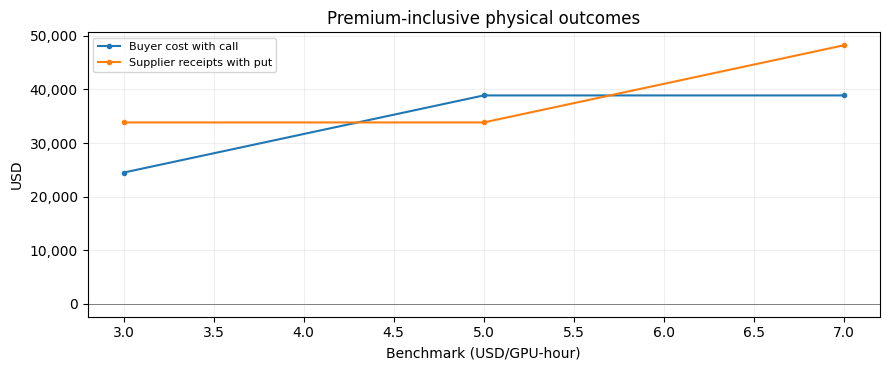

In [5]:
display(
    plot_finance_series(
        {
            "Buyer cost with call": [r[1] for r in base_calls],
            "Supplier receipts with put": [r[1] for r in base_puts],
        },
        title="Premium-inclusive physical outcomes",
        xlabel="Benchmark (USD/GPU-hour)",
        x_values=prices,
    )
)


def option_explorer(values, q=quantity, grid=prices):
    kind = values["Option"]
    premium = values["Premium USD/GPU-hour"]
    if premium < 0:
        raise ValueError("Premium must be nonnegative")
    payoffs = [
        european_option_payoff_usd(
            kind=kind,
            settlement_price_usd_per_gpu_hour=p,
            strike_usd_per_gpu_hour=values["Strike USD/GPU-hour"],
            covered_gpu_hours=q,
        )
        for p in grid
    ]
    amounts = [
        q * p - payoff + q * premium if kind == "call" else q * p + payoff - q * premium
        for p, payoff in zip(grid, payoffs)
    ]
    return {
        "Gross payoff": payoffs,
        "Buyer cost" if kind == "call" else "Supplier receipts": amounts,
    }


explore_finance_series(
    {"Option": "call", "Strike USD/GPU-hour": 5.0, "Premium USD/GPU-hour": 0.40},
    option_explorer,
    choices={"Option": ("call", "put")},
    title="Assumed option terms",
    xlabel="Benchmark (USD/GPU-hour)",
    x_values=prices,
);

The option payment alone does not show what protection costs. Include the premium when reading the buyer's cap or seller's floor.

## Experiment 1 — Increase the premium

Double the call premium to USD 0.80 per hour and the put premium to USD 0.60. Keep the strike and covered hours unchanged.

The option pays exactly the same amount at every final price. Each extra premium dollar raises the buyer's cost or lowers the supplier's net receipts by one dollar. The higher price buys no extra protection under these terms.

In [6]:
expensive_calls = [outcome("call", p, 0.80)[1] for p in prices]
expensive_puts = [outcome("put", p, 0.60)[1] for p in prices]
show_finance_table(
    ["Benchmark", "Buyer cost USD", "Supplier receipts USD"],
    [[p, c, u] for p, c, u in zip(prices, expensive_calls, expensive_puts)],
)

| Benchmark | Buyer cost USD | Supplier receipts USD |
| --- | --- | --- |
| 3.00 | 27,360.00 | 31,680.00 |
| 5.00 | 41,760.00 | 31,680.00 |
| 7.00 | 41,760.00 | 46,080.00 |

The call's cap rises to **USD 5.80 per hour**, or **USD 41,760**. The put's floor falls to **USD 4.40 per hour**, or **USD 31,680**.

The USD 5 strike alone does not describe the full cost or revenue protection; the premium must also be included.

## Experiment 2 — Protect half the hours

Return to the original premiums, but cover only **3,600 of the 7,200 hours**.

The premium bill halves. But the unprotected half still changes with market prices. Protecting half the purchase cannot cap the entire bill.

In [7]:
half_calls = [outcome("call", p, call_premium, covered=3_600)[1] for p in prices]
half_puts = [outcome("put", p, put_premium, covered=3_600)[1] for p in prices]
show_finance_table(
    ["Benchmark", "Half-covered buyer cost USD", "Half-covered supplier receipts USD"],
    [[p, c, u] for p, c, u in zip(prices, half_calls, half_puts)],
)

| Benchmark | Half-covered buyer cost USD | Half-covered supplier receipts USD |
| --- | --- | --- |
| 3.00 | 23,040.00 | 27,720.00 |
| 5.00 | 37,440.00 | 34,920.00 |
| 7.00 | 44,640.00 | 49,320.00 |

At a USD 7 benchmark, the half-protected buyer pays **USD 44,640**, above the fully protected USD 38,880.

At USD 3, the half-protected supplier receives **USD 27,720**, below the fully protected USD 33,840.

## Experiment 3 — Our supplier charges more than the benchmark

Restore full call coverage. Make the actual compute price USD 0.50 per hour higher than the benchmark.

This brings back M3's price difference, or basis. The call follows the benchmark, not the supplier's extra charge. The constant difference adds **USD 3,600**; a growing difference could add more.

In [8]:
basis_calls = [outcome("call", p, call_premium, basis=0.50)[1] for p in prices]
show_finance_table(
    ["Benchmark", "Actual purchase rate", "Buyer cost USD"],
    [[p, p + 0.50, cost] for p, cost in zip(prices, basis_calls)],
)

| Benchmark | Actual purchase rate | Buyer cost USD |
| --- | --- | --- |
| 3.00 | 3.50 | 28,080.00 |
| 5.00 | 5.50 | 42,480.00 |
| 7.00 | 7.50 | 42,480.00 |

At a USD 7 benchmark, buyer cost is now **USD 42,480**, or **USD 5.90 per purchased hour**.

The call still pays according to its rules. But the business also pays the supplier's extra charge.

Before calling a result a cap or floor, check the covered hours and whether the actual price matches the reference price. Keep cash ready for the upfront premium, and check who owes the option payment.

We have calculated payments under stated terms. We have not calculated what a seller should charge for this protection.

In [9]:
show_finance_table(
    ["Buyer case at benchmark 7", "Nominal cost USD"],
    [
        ["Full matched call", base_calls[-1][1]],
        ["Higher premium", expensive_calls[-1]],
        ["Half coverage", half_calls[-1]],
        ["Actual price above benchmark", basis_calls[-1]],
    ],
)

| Buyer case at benchmark 7 | Nominal cost USD |
| --- | --- |
| Full matched call | 38,880.00 |
| Higher premium | 41,760.00 |
| Half coverage | 44,640.00 |
| Actual price above benchmark | 42,480.00 |

The matched call lets the buyer benefit when compute gets cheaper. The matched put lets the supplier benefit when its selling price rises. Premium is the price paid for that flexibility.

Neither option guarantees physical service, payment by the other party or profit after all other costs.

**Next: M6, Option valuation.** It shows a small model for an option price and the assumptions needed to use it. Its pricing weights have a different purpose from probabilities used to forecast business outcomes.

Our examples omit taxes, fees, default and collateral. [OIC's pricing concepts](https://www.optionseducation.org/optionsoverview/options-pricing) provide background, not real compute quotes.